# 02 — Exploratory Data Analysis (EDA)

Analyse descriptive, analyse du target, variables numériques/catégorielles, corrélation, feature engineering et sauvegarde du dataset.

## Imports

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
DATA_PATH = Path("../data/processed/dataset_delivery_time_clean.csv")
df = pd.read_csv(DATA_PATH)

numeric_cols = [
    "Restaurant_latitude",
    "Restaurant_longitude",
    "Delivery_location_latitude",
    "Delivery_location_longitude",
    "Time_taken(min)",
    "distance_km",
    "pickup_hour",
    "pickup_minute",
    "is_peak_hour",
]
categorical_cols = ["Weatherconditions", "Road_traffic_density", "Type_of_vehicle"]
target = "Time_taken(min)"

print(f"Shape: {df.shape}")
df.head()

Shape: (41953, 13)


,ID,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Weatherconditions,Road_traffic_density,Type_of_vehicle,Time_taken(min),distance_km,pickup_hour,pickup_minute,is_peak_hour
0,0x4607,22.745049,75.892471,22.765049,75.912471,Sunny,High,motorcycle,24,3.025149,11,45,0
1,0xb379,12.913041,77.683237,13.043041,77.813237,Stormy,Jam,scooter,33,20.183530,19,50,1
2,0x5d6d,12.914264,77.678400,12.924264,77.688400,Sandstorms,Low,motorcycle,26,1.552758,8,45,0
3,0x7a6a,11.003669,76.976494,11.053669,77.026494,Sunny,Medium,motorcycle,21,7.790401,18,10,0
4,0x70a2,12.972793,80.249982,13.012793,80.289982,Cloudy,High,scooter,30,6.210138,13,45,1


## Charger le dataset

In [3]:
print("Dimensions:", df.shape)
print("\nColonnes:", df.columns.tolist())
print("\nTypes:\n", df.dtypes)
print("\nValeurs manquantes:\n", df.isna().sum())
print("\nDoublons:", df.duplicated().sum())

Dimensions: (41953, 13)

Colonnes: ['ID', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Weatherconditions', 'Road_traffic_density', 'Type_of_vehicle', 'Time_taken(min)', 'distance_km', 'pickup_hour', 'pickup_minute', 'is_peak_hour']

Types:
 ID                                 str
Restaurant_latitude            float64
Restaurant_longitude           float64
Delivery_location_latitude     float64
Delivery_location_longitude    float64
Weatherconditions                  str
Road_traffic_density               str
Type_of_vehicle                    str
Time_taken(min)                  int64
distance_km                    float64
pickup_hour                      int64
pickup_minute                    int64
is_peak_hour                     int64
dtype: object

Valeurs manquantes:
 ID                               0
Restaurant_latitude              0
Restaurant_longitude             0
Delivery_location_latitude       0
Delivery_loc

## Vérification générale

In [17]:
df[numeric_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Restaurant_latitude,41953.0,18.49,6.75,-30.91,12.98,19.00,22.75,30.91
Restaurant_longitude,41953.0,76.32,10.20,-88.37,73.90,76.62,78.35,88.43
Delivery_location_latitude,41953.0,18.98,5.47,9.97,13.07,19.12,22.82,31.05
Delivery_location_longitude,41953.0,76.99,3.50,72.78,73.94,76.66,78.41,88.56
Time_taken(min),41953.0,26.31,9.38,10.00,19.00,26.00,32.00,54.00
distance_km,41953.0,107.06,1146.12,1.47,4.66,9.22,13.76,19692.67
pickup_hour,41953.0,17.15,5.32,0.00,14.00,19.00,21.00,23.00
pickup_minute,41953.0,28.60,17.57,0.00,15.00,30.00,45.00,55.00
is_peak_hour,41953.0,0.36,0.48,0.00,0.00,0.00,1.00,1.00


# 1. Analyse descriptive

### Variables numériques

In [4]:
descriptive_stats = pd.DataFrame({
    "Mean": df[numeric_cols].mean(),
    "Median": df[numeric_cols].median(),
    "Std": df[numeric_cols].std(),
    "Min": df[numeric_cols].min(),
    "Max": df[numeric_cols].max(),
}).round(2)

descriptive_stats

,Mean,Median,Std,Min,Max
Restaurant_latitude,18.49,19.00,6.75,-30.91,30.91
Restaurant_longitude,76.32,76.62,10.20,-88.37,88.43
Delivery_location_latitude,18.98,19.12,5.47,9.97,31.05
Delivery_location_longitude,76.99,76.66,3.50,72.78,88.56
Time_taken(min),26.31,26.00,9.38,10.00,54.00
distance_km,107.06,9.22,1146.12,1.47,19692.67
pickup_hour,17.15,19.00,5.32,0.00,23.00
pickup_minute,28.60,30.00,17.57,0.00,55.00
is_peak_hour,0.36,0.00,0.48,0.00,1.00


### Mean / Median / Standard Deviation

In [5]:
descriptive_stats = pd.DataFrame({
    "Mean": df[numeric_cols].mean(),
    "Median": df[numeric_cols].median(),
    "Std": df[numeric_cols].std()
})

descriptive_stats

,Mean,Median,Std
Restaurant_latitude,18.494251,19.003517,6.745454
Restaurant_longitude,76.324867,76.618203,10.197937
Delivery_location_latitude,18.975064,19.123249,5.469616
Delivery_location_longitude,76.987074,76.663622,3.503073
Time_taken(min),26.311539,26.000000,9.380753
distance_km,107.060101,9.220368,1146.118637
pickup_hour,17.145758,19.000000,5.321714
pickup_minute,28.596525,30.000000,17.568830
is_peak_hour,0.356685,0.000000,0.479026


### Variables catégorielles

In [6]:
for col in categorical_cols:
    print(f"\n===== {col} =====")
    display(df[col].value_counts(dropna=False).to_frame("count"))


===== Weatherconditions =====


,count
Weatherconditions,
Fog,7012
Stormy,6974
Cloudy,6932
Sandstorms,6906
Windy,6832
Sunny,6728
NaN,569



===== Road_traffic_density =====


,count
Road_traffic_density,
Low,14755
Jam,13043
Medium,10084
High,4071



===== Type_of_vehicle =====


,count
Type_of_vehicle,
motorcycle,24396
scooter,14029
electric_scooter,3468
bicycle,60


### Pourcentage des catégories

In [ ]:
category_percentages = {}
for col in categorical_cols:
    category_percentages[col] = (
        df[col].value_counts(normalize=True, dropna=False).mul(100).round(2)
    )

category_percentages


===== Weather =====
Weather
Clear    48.45
Rainy    21.03
Foggy    10.62
Snowy    10.00
Windy     9.90
Name: proportion, dtype: float64

===== Traffic_Level =====
Traffic_Level
Medium    40.21
Low       39.48
High      20.31
Name: proportion, dtype: float64

===== Time_of_Day =====
Time_of_Day
Morning      31.75
Evening      30.21
Afternoon    29.28
Night         8.76
Name: proportion, dtype: float64

===== Vehicle_Type =====
Vehicle_Type
Bike       50.3
Scooter    30.2
Car        19.5
Name: proportion, dtype: float64


# 2. Analyse du Target

### Définir le target

In [7]:
target = "Time_taken(min)"
print("Target:", target)
print(df[target].describe().round(2))

Target: Time_taken(min)
count    41953.00
mean        26.31
std          9.38
min         10.00
25%         19.00
50%         26.00
75%         32.00
max         54.00
Name: Time_taken(min), dtype: float64


### Distribution du temps de livraison

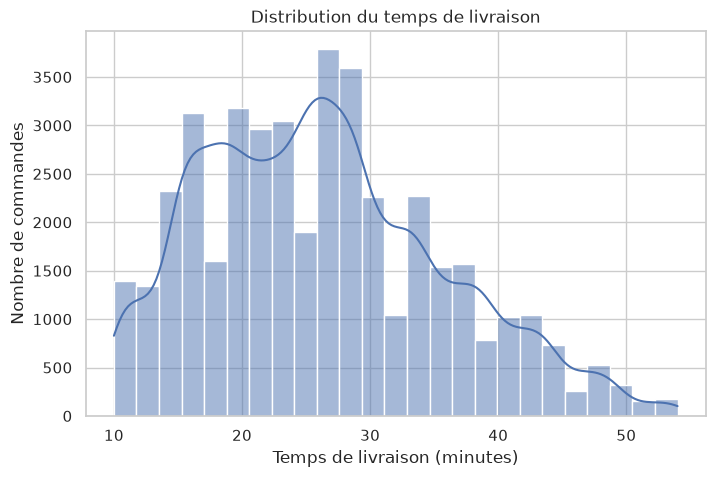

In [8]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x=target, bins=25, kde=True)
plt.title("Distribution du temps de livraison")
plt.xlabel("Temps de livraison (minutes)")
plt.ylabel("Nombre de commandes")
plt.show()

### Boxplot du target

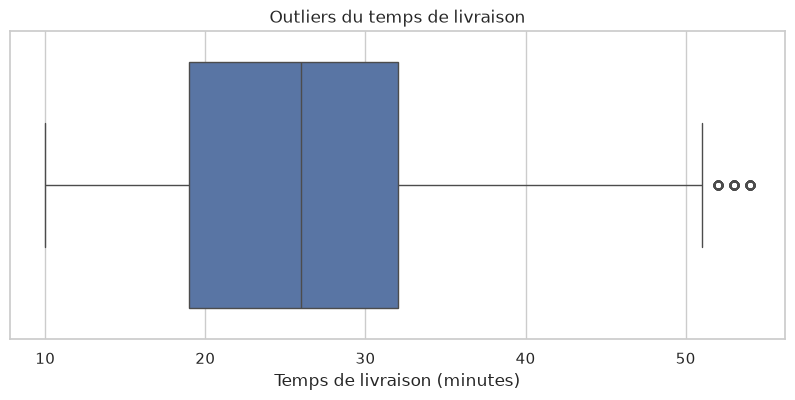

In [9]:
plt.figure(figsize=(10, 4))
sns.boxplot(data=df, x=target)
plt.title("Outliers du temps de livraison")
plt.xlabel("Temps de livraison (minutes)")
plt.show()

# 3. Variables numériques vs Target

### Distance

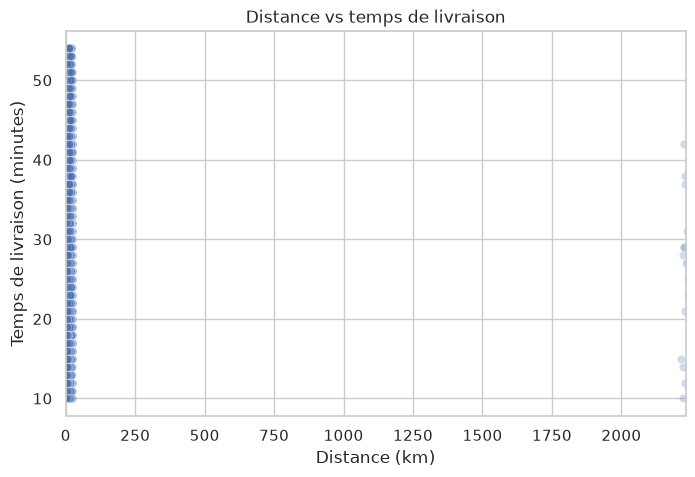

In [10]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="distance_km", y=target, alpha=0.25)
plt.title("Distance vs temps de livraison")
plt.xlabel("Distance (km)")
plt.ylabel("Temps de livraison (minutes)")
plt.xlim(0, df["distance_km"].quantile(0.99))
plt.show()

### Preparation Time

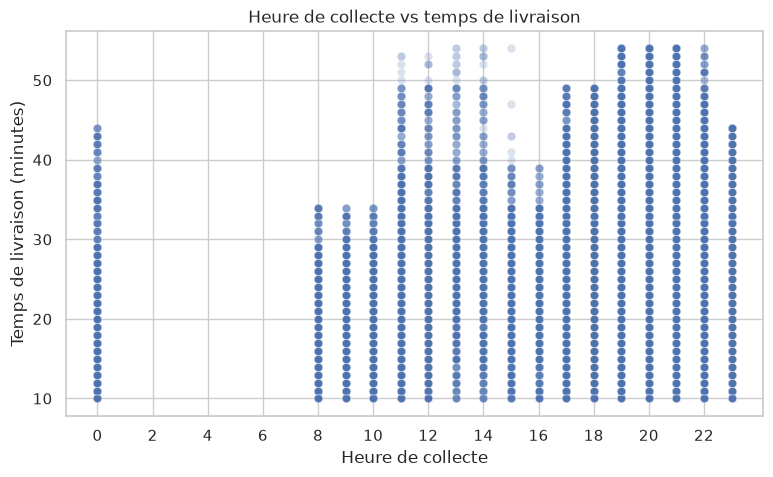

In [11]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x="pickup_hour", y=target, alpha=0.2)
plt.title("Heure de collecte vs temps de livraison")
plt.xlabel("Heure de collecte")
plt.ylabel("Temps de livraison (minutes)")
plt.xticks(range(0, 24, 2))
plt.show()

### Courier Experience

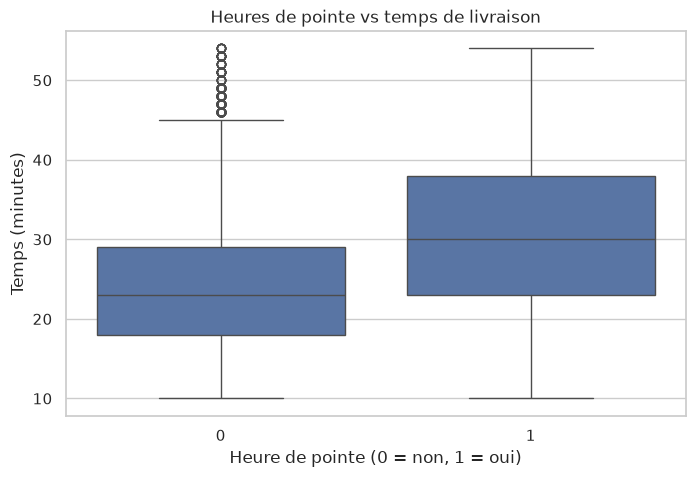

In [12]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="is_peak_hour", y=target)
plt.title("Heures de pointe vs temps de livraison")
plt.xlabel("Heure de pointe (0 = non, 1 = oui)")
plt.ylabel("Temps (minutes)")
plt.show()

# 4. Variables catégorielles vs Target

### Weather

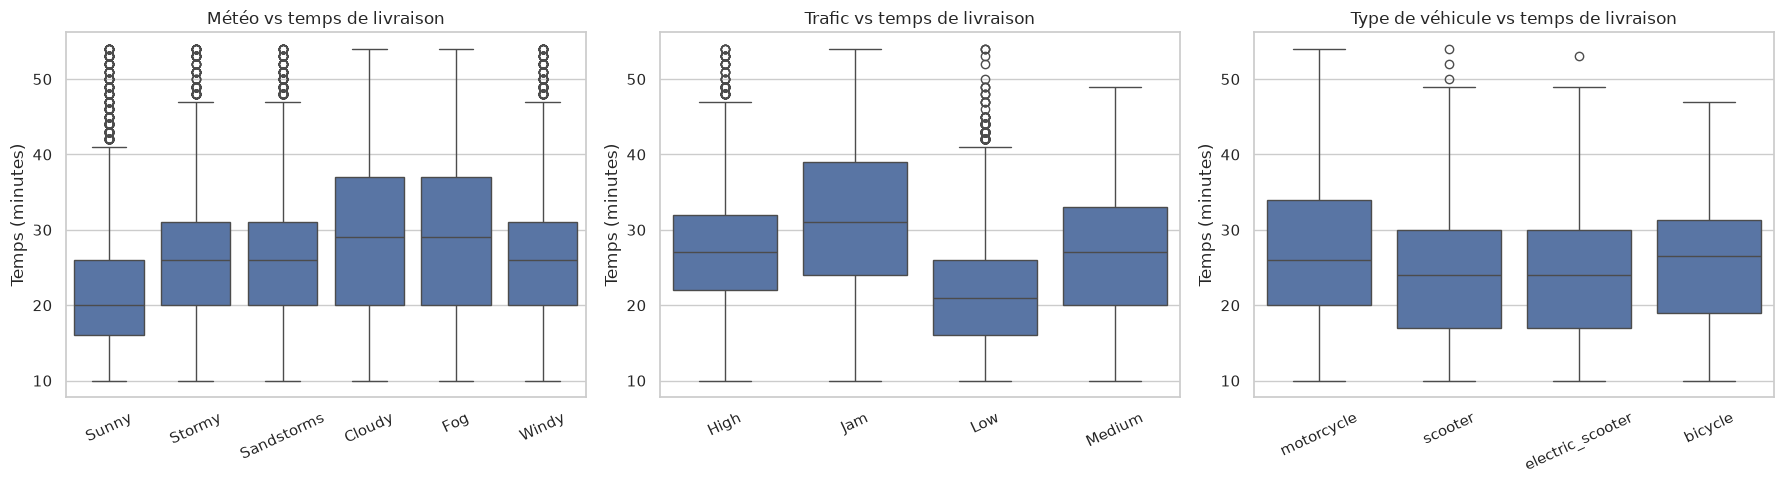

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col, title in zip(
    axes,
    categorical_cols,
    ["Météo", "Trafic", "Type de véhicule"],
):
    sns.boxplot(data=df, x=col, y=target, ax=ax)
    ax.set_title(f"{title} vs temps de livraison")
    ax.tick_params(axis="x", rotation=25)
    ax.set_xlabel("")
    ax.set_ylabel("Temps (minutes)")
plt.tight_layout()
plt.show()

### Traffic Level

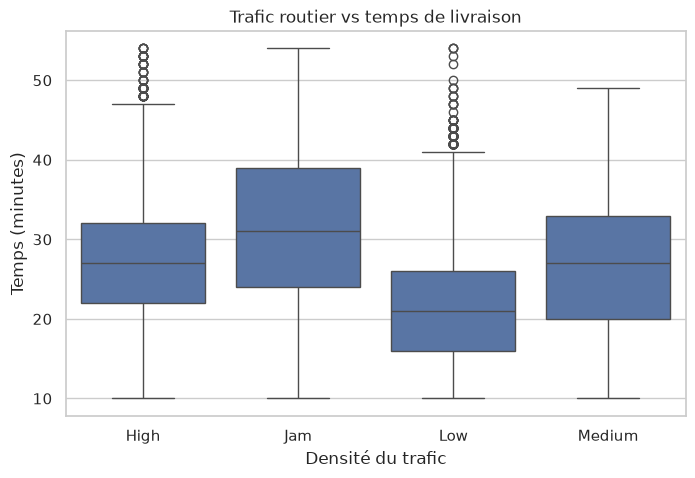

In [14]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Road_traffic_density", y=target)
plt.title("Trafic routier vs temps de livraison")
plt.xlabel("Densité du trafic")
plt.ylabel("Temps (minutes)")
plt.show()

### Time of Day

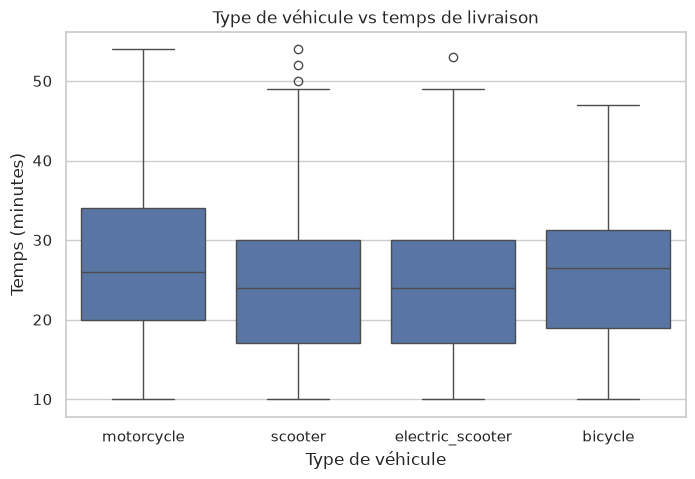

In [15]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Type_of_vehicle", y=target)
plt.title("Type de véhicule vs temps de livraison")
plt.xlabel("Type de véhicule")
plt.ylabel("Temps (minutes)")
plt.show()

### Vehicle Type

In [16]:
hour_summary = df.groupby("pickup_hour")[target].agg(["mean", "median", "count"]).round(2)
hour_summary

,mean,median,count
pickup_hour,,,
0,22.31,21.0,1212
8,19.59,19.0,1378
9,19.54,19.0,1885
10,19.49,19.0,1937
11,25.08,25.0,1827
12,27.03,27.0,1075
13,27.62,27.0,735
14,27.64,27.0,749
15,23.81,25.0,830


# 5. Analyse statistique par catégorie

### Weather

In [27]:
weather_summary = df.groupby("Weatherconditions", dropna=False)[target].agg(
    ["mean", "median", "std", "count"]
).round(2)
weather_summary

,mean,median,std,count
Weatherconditions,,,,
Cloudy,28.93,29.0,10.02,6932
Fog,28.97,29.0,10.13,7012
Sandstorms,25.88,26.0,8.64,6906
Stormy,25.90,26.0,8.49,6974
Sunny,21.90,20.0,8.36,6728
Windy,26.13,26.0,8.62,6832
NaN,26.34,26.0,9.40,569


### Traffic

In [28]:
traffic_summary = df.groupby("Road_traffic_density")[target].agg(
    ["mean", "median", "std", "count"]
).round(2)
traffic_summary

,mean,median,std,count
Road_traffic_density,,,,
High,27.23,27.0,8.42,4071
Jam,31.18,31.0,9.94,13043
Low,21.47,21.0,7.00,14755
Medium,26.73,27.0,8.53,10084


### Time of Day

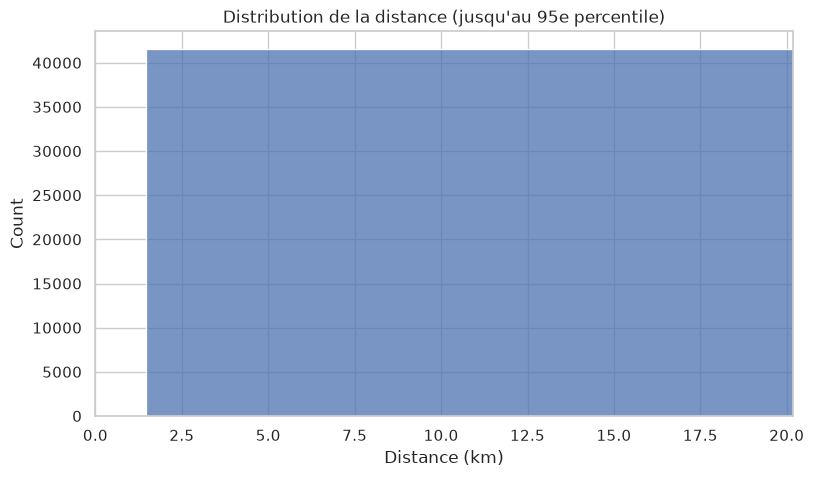

In [17]:
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x="distance_km", bins=50)
plt.xlim(0, df["distance_km"].quantile(0.95))
plt.title("Distribution de la distance (jusqu'au 95e percentile)")
plt.xlabel("Distance (km)")
plt.show()

### Vehicle

In [31]:
vehicle_summary = df.groupby("Type_of_vehicle")[target].agg(
    ["mean", "median", "std", "count"]
).round(2)
vehicle_summary

,mean,median,std,count
Type_of_vehicle,,,,
bicycle,26.42,26.5,8.96,60
electric_scooter,24.46,24.0,8.64,3468
motorcycle,27.61,26.0,9.64,24396
scooter,24.51,24.0,8.71,14029


# 6. Matrice de corrélation

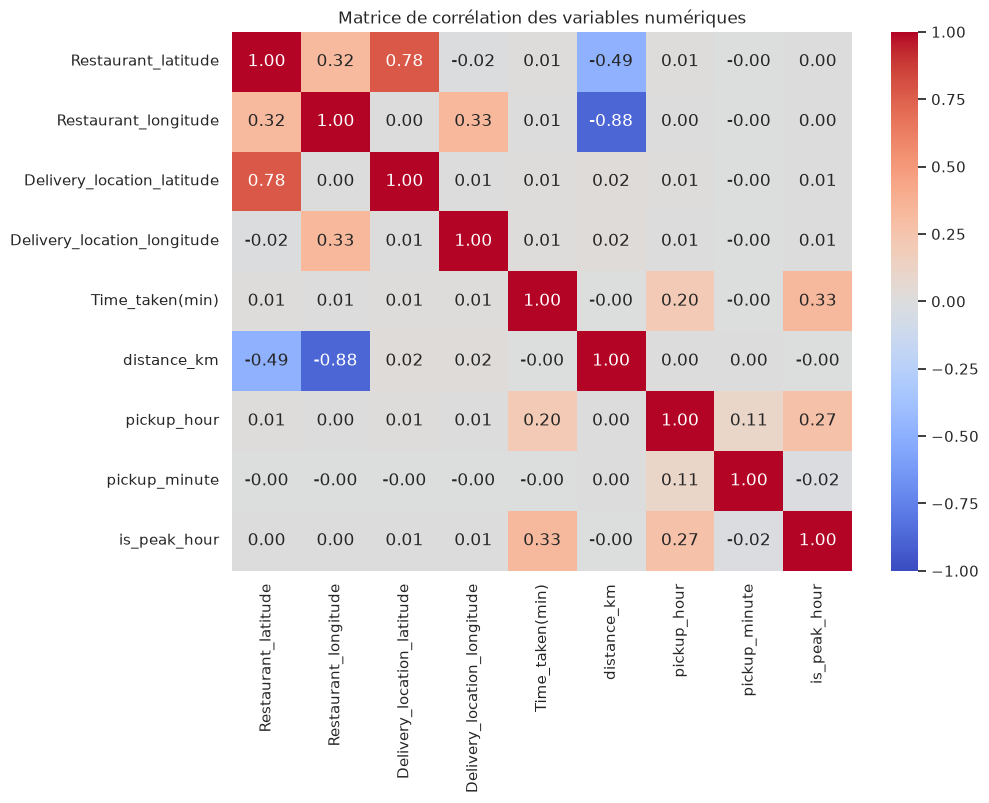

In [18]:
correlation_matrix = df[numeric_cols].corr()
plt.figure(figsize=(10, 7))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Matrice de corrélation des variables numériques")
plt.show()

In [19]:
target_correlation = (
    correlation_matrix[target]
    .drop(target)
    .sort_values(key=abs, ascending=False)
    .to_frame("correlation")
)
target_correlation

,correlation
is_peak_hour,0.326073
pickup_hour,0.203252
Delivery_location_latitude,0.014335
Restaurant_latitude,0.013493
Delivery_location_longitude,0.010042
Restaurant_longitude,0.005570
distance_km,-0.002911
pickup_minute,-0.002456


### Corrélation avec le Target

In [20]:
# Distance outliers are reported, not removed automatically.
outlier_summary = {}
for col in ["distance_km", target]:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_summary[col] = {
        "lower_bound": round(lower, 2),
        "upper_bound": round(upper, 2),
        "count": int(((df[col] < lower) | (df[col] > upper)).sum()),
    }

pd.DataFrame(outlier_summary).T

,lower_bound,upper_bound,count
distance_km,-9.0,27.42,431.0
Time_taken(min),-0.5,51.50,247.0


# 7. Feature Engineering

Au moins **2 nouvelles features**.

### Feature 1 — Preparation Time per KM

`Preparation_Time_min / Distance_km`

In [21]:
peak_summary = df.groupby("is_peak_hour")[target].agg(
    ["mean", "median", "std", "count"]
).round(2)
peak_summary

,mean,median,std,count
is_peak_hour,,,,
0,24.03,23.0,8.28,26989
1,30.42,30.0,9.83,14964


### Feature 2 — Traffic Score

Low → 1, Medium → 2, High → 3

In [22]:
traffic_mapping = {"Low": 1, "Medium": 2, "High": 3, "Jam": 4}
df["Traffic_Score"] = df["Road_traffic_density"].map(traffic_mapping)
df[["Road_traffic_density", "Traffic_Score"]].drop_duplicates().sort_values("Traffic_Score")

,Road_traffic_density,Traffic_Score
2,Low,1
3,Medium,2
0,High,3
1,Jam,4


### Feature 3 — Distance × Traffic

In [23]:
df["Distance_Traffic"] = df["distance_km"] * df["Traffic_Score"]
df[["distance_km", "Traffic_Score", "Distance_Traffic"]].describe().round(2)

,distance_km,Traffic_Score,Distance_Traffic
count,41953.00,41953.00,41953.00
mean,107.06,2.37,182.86
std,1146.12,1.25,2018.84
min,1.47,1.00,1.47
25%,4.66,1.00,9.19
50%,9.22,2.00,18.36
75%,13.76,4.00,36.88
max,19692.67,4.00,78752.01


# 8. Vérification finale

In [24]:
print("Dimensions finales:", df.shape)
print("Colonnes finales:", df.columns.tolist())
print("\nValeurs manquantes:")
print(df.isna().sum())
print("\nStatistiques des features ajoutées:")
display(df[["Traffic_Score", "Distance_Traffic"]].describe().round(2))

Dimensions finales: (41953, 15)
Colonnes finales: ['ID', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Weatherconditions', 'Road_traffic_density', 'Type_of_vehicle', 'Time_taken(min)', 'distance_km', 'pickup_hour', 'pickup_minute', 'is_peak_hour', 'Traffic_Score', 'Distance_Traffic']

Valeurs manquantes:
ID                               0
Restaurant_latitude              0
Restaurant_longitude             0
Delivery_location_latitude       0
Delivery_location_longitude      0
Weatherconditions              569
Road_traffic_density             0
Type_of_vehicle                  0
Time_taken(min)                  0
distance_km                      0
pickup_hour                      0
pickup_minute                    0
is_peak_hour                     0
Traffic_Score                    0
Distance_Traffic                 0
dtype: int64

Statistiques des features ajoutées:


,Traffic_Score,Distance_Traffic
count,41953.00,41953.00
mean,2.37,182.86
std,1.25,2018.84
min,1.00,1.47
25%,1.00,9.19
50%,2.00,18.36
75%,4.00,36.88
max,4.00,78752.01


# 9. Sauvegarder le dataset

In [31]:
output_path = "../data/processed/dataset_delivery_eda.csv"

df.to_csv(
    output_path,
    index=False
)

print("Dataset EDA sauvegardé avec succès.")
print("Fichier :", output_path)

Dataset EDA sauvegardé avec succès.
Fichier : ../data/processed/dataset_delivery_eda.csv


,Model,MAE,MSE,RMSE,R2
0,Gradient Boosting,5.3884,46.1405,6.7927,0.4645
1,Random Forest,5.5352,50.2251,7.0870,0.4170
2,Ridge,6.3565,62.8142,7.9255,0.2709
3,Linear Regression,6.3565,62.8143,7.9255,0.2709


In [34]:
model_results.to_csv("../reports/model_results.csv", index=False)
print("Model results saved to ../reports/model_results.csv")

Model results saved to ../reports/model_results.csv


In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41953 entries, 0 to 41952
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           41953 non-null  str    
 1   Restaurant_latitude          41953 non-null  float64
 2   Restaurant_longitude         41953 non-null  float64
 3   Delivery_location_latitude   41953 non-null  float64
 4   Delivery_location_longitude  41953 non-null  float64
 5   Weatherconditions            41384 non-null  str    
 6   Road_traffic_density         41953 non-null  str    
 7   Type_of_vehicle              41953 non-null  str    
 8   Time_taken(min)              41953 non-null  int64  
 9   distance_km                  41953 non-null  float64
 10  pickup_hour                  41953 non-null  int64  
 11  pickup_minute                41953 non-null  int64  
 12  is_peak_hour                 41953 non-null  int64  
 13  Traffic_Score              